# Project 3: Regime-Conditioned Factor Allocation

### Investment thesis
Macro fundamentals determine which risk premia get rewarded. By classifying the current
macro state into regimes and tilting toward historically strong factors in each regime,
we improve factor portfolio Sharpe over equal-weight.

### This notebook
- **Section 3**: Regime count sweep (k=2,3,4,5)
- **Section 4**: Hyperparameter grid (PCA components, GMM covariance, refit frequency)
- **Section 5**: Transaction cost analysis
- **Section 6**: Training window robustness
- **Section 7**: Best configuration deep-dive + statistical tests

### Prerequisites
Run `P1_data_infrastructure.ipynb` first.
```
pip install pandas numpy scikit-learn matplotlib pandas_datareader scipy
```

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, time, warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from scipy import stats
from itertools import product

DATA_DIR = './data'
RESULTS_DIR = './results'
os.makedirs(RESULTS_DIR, exist_ok=True)

## 1. Load data

In [2]:
import pandas_datareader.data as web

ff5 = web.DataReader('F-F_Research_Data_5_Factors_2x3', 'famafrench', start='1963-01-01')
mom = web.DataReader('F-F_Momentum_Factor', 'famafrench', start='1963-01-01')
factors_all = ff5[0].join(mom[0]) / 100
factors_all.index = factors_all.index.to_timestamp()

factor_names = ['SMB', 'HML', 'RMW', 'CMA', 'Mom']
factor_returns = factors_all[factor_names].copy()

monthly_macro = pd.read_csv(f'{DATA_DIR}/monthly_panel_transformed.csv', index_col=0, parse_dates=True)
quarterly_macro = pd.read_csv(f'{DATA_DIR}/quarterly_panel_transformed.csv', index_col=0, parse_dates=True)
assert monthly_macro.shape[1] > 0

quarterly_ffill = quarterly_macro.resample('MS').ffill()
macro_panel = pd.concat([monthly_macro, quarterly_ffill], axis=1).ffill().bfill().fillna(0)
macro_panel = macro_panel.dropna(axis=1, how='all')

common_start = max(macro_panel.index.min(), factor_returns.index.min())
common_end = min(macro_panel.index.max(), factor_returns.index.max())
common_idx = macro_panel[common_start:common_end].index.intersection(
    factor_returns[common_start:common_end].index)
macro_aligned = macro_panel.loc[common_idx]
factors_aligned = factor_returns.loc[common_idx]

print(f'Macro: {macro_aligned.shape}, Factors: {factors_aligned.shape}')

Macro: (502, 32), Factors: (502, 5)


## 2. Strategy engine

In [3]:
def compute_regime_weights(factor_rets_hist, regime_hist, current_regime, n_factors):
    mask = regime_hist == current_regime
    if mask.sum() < 6:
        return np.ones(n_factors) / n_factors
    regime_avg = factor_rets_hist[mask].mean()
    ranks = regime_avg.rank(ascending=True)
    weights = ranks / ranks.sum()
    weights = np.maximum(weights.values, 0.05)
    return weights / weights.sum()


def run_regime_strategy(macro_aligned, factors_aligned, factor_names,
                        n_regimes=3, n_pca=5, init_train_pct=0.50,
                        refit_every=12, cov_type='full', tc_bps=0):
    """
    Full walk-forward regime-conditioned factor allocation.
    
    Args:
        tc_bps: transaction cost in basis points per unit of turnover
    """
    N = len(macro_aligned)
    init_train = int(N * init_train_pct)
    n_factors = len(factor_names)
    tc = tc_bps / 10000  # convert bps to decimal
    
    strat_rets, eq_rets, static_rets = [], [], []
    strat_weights, strat_regimes, strat_dates = [], [], []
    prev_w = np.ones(n_factors) / n_factors
    last_refit = -999
    
    for t in range(init_train, N):
        date = macro_aligned.index[t]
        actual_rets = factors_aligned.iloc[t].values
        
        if t - last_refit >= refit_every or t == init_train:
            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(macro_aligned.iloc[:t])
            n_pca_safe = min(n_pca, X_scaled.shape[1], X_scaled.shape[0])
            pca = PCA(n_components=n_pca_safe)
            X_pca = pca.fit_transform(X_scaled)
            gmm = GaussianMixture(n_components=n_regimes, covariance_type=cov_type,
                                   n_init=10, random_state=42)
            gmm.fit(X_pca)
            last_refit = t
        
        x_now = pca.transform(scaler.transform(macro_aligned.iloc[[t]]))
        regime = gmm.predict(x_now)[0]
        
        past_factors = factors_aligned.iloc[:t]
        past_regimes = pd.Series(
            gmm.predict(pca.transform(scaler.transform(macro_aligned.iloc[:t]))),
            index=macro_aligned.index[:t])
        common = past_factors.index.intersection(past_regimes.index)
        
        w = compute_regime_weights(past_factors.loc[common], past_regimes.loc[common],
                                   regime, n_factors)
        w_eq = np.ones(n_factors) / n_factors
        
        static_avg = past_factors.mean()
        static_ranks = static_avg.rank(ascending=True)
        w_static = np.maximum((static_ranks / static_ranks.sum()).values, 0.05)
        w_static = w_static / w_static.sum()
        
        # Apply transaction costs
        turnover = np.sum(np.abs(w - prev_w))
        tc_cost = turnover * tc
        
        strat_rets.append(np.sum(w * actual_rets) - tc_cost)
        eq_rets.append(np.sum(w_eq * actual_rets))
        static_rets.append(np.sum(w_static * actual_rets))
        strat_weights.append(w)
        strat_regimes.append(regime)
        strat_dates.append(date)
        prev_w = w.copy()
    
    return {
        'strat_rets': np.array(strat_rets), 'eq_rets': np.array(eq_rets),
        'static_rets': np.array(static_rets), 'weights': np.array(strat_weights),
        'regimes': np.array(strat_regimes), 'dates': np.array(strat_dates),
    }


def compute_metrics(rets, name=''):
    cum = np.cumprod(1 + rets)
    n_years = len(rets) / 12
    total = cum[-1] - 1
    ann_ret = (1 + total)**(1/n_years) - 1 if n_years > 0 else 0
    ann_vol = np.std(rets) * np.sqrt(12)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else 0
    peak = np.maximum.accumulate(cum)
    max_dd = ((cum - peak)/peak).min()
    calmar = ann_ret / abs(max_dd) if max_dd != 0 else 0
    return {'model': name, 'Ann. Return': ann_ret, 'Ann. Vol': ann_vol,
            'Sharpe': sharpe, 'Max DD': max_dd, 'Calmar': calmar}

print('Strategy engine defined.')

Strategy engine defined.


## 3. Regime count sweep (k=2,3,4,5)
Does the strategy work across regime counts, or is one k a lucky choice?

In [4]:
sweep_results = {}
sweep_metrics = []

for k in [2, 3, 4, 5]:
    r = run_regime_strategy(macro_aligned, factors_aligned, factor_names, n_regimes=k)
    sweep_results[k] = r
    m = compute_metrics(r['strat_rets'], f'k={k}')
    m_eq = compute_metrics(r['eq_rets'], '')
    regime_changes = np.sum(np.diff(r['regimes']) != 0)
    m['Regime Changes %'] = regime_changes / len(r['regimes'])
    m['EW Sharpe'] = m_eq['Sharpe']
    sweep_metrics.append(m)
    
    # Distribution
    dist = ' '.join([f'R{i}:{(r["regimes"]==i).sum()}' for i in range(k)])
    print(f'k={k}: Sharpe={m["Sharpe"]:.3f} (EW={m_eq["Sharpe"]:.3f}), {dist}')

sweep_df = pd.DataFrame(sweep_metrics).set_index('model')
print(f'\n{sweep_df[["Sharpe","EW Sharpe","Ann. Return","Max DD","Regime Changes %"]].round(4).to_string()}')

k=2: Sharpe=0.282 (EW=0.140), R0:136 R1:115
k=3: Sharpe=0.362 (EW=0.140), R0:72 R1:117 R2:62
k=4: Sharpe=0.244 (EW=0.140), R0:119 R1:55 R2:54 R3:23
k=5: Sharpe=0.174 (EW=0.140), R0:61 R1:35 R2:91 R3:37 R4:27

       Sharpe  EW Sharpe  Ann. Return  Max DD  Regime Changes %
model                                                          
k=2    0.2817       0.14       0.0138 -0.1544            0.1235
k=3    0.3623       0.14       0.0173 -0.1677            0.1753
k=4    0.2440       0.14       0.0110 -0.1768            0.3546
k=5    0.1741       0.14       0.0089 -0.2074            0.4980


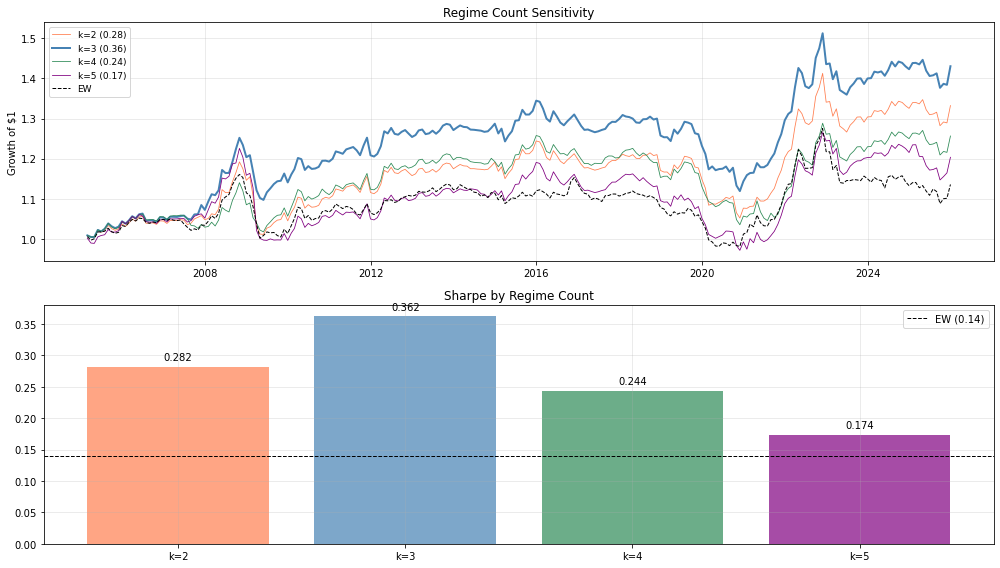

In [5]:
# Plot regime count comparison
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

colors_k = {2:'coral', 3:'steelblue', 4:'seagreen', 5:'purple'}
for k, r in sweep_results.items():
    cum = np.cumprod(1 + r['strat_rets'])
    s = compute_metrics(r['strat_rets'])['Sharpe']
    lw = 2.0 if k == 3 else 0.8
    axes[0].plot(r['dates'], cum, color=colors_k[k], lw=lw, label=f'k={k} ({s:.2f})')
eq_cum = np.cumprod(1 + sweep_results[3]['eq_rets'])
axes[0].plot(sweep_results[3]['dates'], eq_cum, 'k--', lw=1, label='EW')
axes[0].set_title('Regime Count Sensitivity'); axes[0].set_ylabel('Growth of $1')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

sharpes = [compute_metrics(sweep_results[k]['strat_rets'])['Sharpe'] for k in [2,3,4,5]]
eq_s = compute_metrics(sweep_results[3]['eq_rets'])['Sharpe']
bars = axes[1].bar([f'k={k}' for k in [2,3,4,5]], sharpes, color=[colors_k[k] for k in [2,3,4,5]], alpha=0.7)
axes[1].axhline(eq_s, color='k', ls='--', lw=1, label=f'EW ({eq_s:.2f})')
for b, s in zip(bars, sharpes): axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f'{s:.3f}', ha='center')
axes[1].set_title('Sharpe by Regime Count'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig(f'{RESULTS_DIR}/regime_sweep.png', dpi=150); plt.show()

## 4. Hyperparameter sensitivity
Test PCA components (3,5,7,10), GMM covariance ('full','diag'), refit frequency (6,12,24).

In [6]:
# Grid search over hyperparameters (using best k from sweep)
best_k = max(sweep_results.keys(), key=lambda k: compute_metrics(sweep_results[k]['strat_rets'])['Sharpe'])
print(f'Using best k={best_k} from sweep\n')

pca_vals = [3, 5, 7, 10]
cov_vals = ['full', 'diag']
refit_vals = [6, 12, 24]

grid_results = []
start_time = time.time()

for n_pca, cov, refit in product(pca_vals, cov_vals, refit_vals):
    r = run_regime_strategy(macro_aligned, factors_aligned, factor_names,
                            n_regimes=best_k, n_pca=n_pca, refit_every=refit, cov_type=cov)
    m = compute_metrics(r['strat_rets'])
    regime_changes = np.sum(np.diff(r['regimes']) != 0)
    grid_results.append({
        'PCA': n_pca, 'Cov': cov, 'Refit': refit,
        'Sharpe': m['Sharpe'], 'Return': m['Ann. Return'],
        'Max DD': m['Max DD'], 'Regime Chg %': regime_changes/len(r['regimes']),
    })

print(f'Grid search done. {time.time()-start_time:.0f}s ({len(grid_results)} configs)\n')

grid_df = pd.DataFrame(grid_results).sort_values('Sharpe', ascending=False)
print('=== Top 10 Configurations ===')
print(grid_df.head(10).to_string(index=False))
print(f'\n=== Bottom 5 ===')
print(grid_df.tail(5).to_string(index=False))

eq_sharpe = compute_metrics(sweep_results[best_k]['eq_rets'])['Sharpe']
n_beat_ew = (grid_df['Sharpe'] > eq_sharpe).sum()
print(f'\n{n_beat_ew}/{len(grid_df)} configs beat equal-weight (Sharpe={eq_sharpe:.3f})')

Using best k=3 from sweep

Grid search done. 130s (24 configs)

=== Top 10 Configurations ===
 PCA  Cov  Refit   Sharpe   Return    Max DD  Regime Chg %
  10 full     24 0.391318 0.017438 -0.184447      0.298805
   5 full     24 0.381037 0.018455 -0.168470      0.155378
   5 full     12 0.362255 0.017260 -0.167684      0.175299
   5 full      6 0.330058 0.015896 -0.169469      0.215139
  10 full     12 0.318826 0.014060 -0.171828      0.310757
   7 full     24 0.312025 0.015785 -0.187261      0.199203
   3 full      6 0.290474 0.013859 -0.167574      0.270916
   3 full     24 0.289587 0.013528 -0.189505      0.211155
  10 full      6 0.275599 0.013108 -0.167797      0.334661
   3 full     12 0.272691 0.013062 -0.181732      0.187251

=== Bottom 5 ===
 PCA  Cov  Refit   Sharpe   Return    Max DD  Regime Chg %
   7 diag     24 0.116087 0.006004 -0.221875      0.223108
  10 diag      6 0.097603 0.005019 -0.218833      0.310757
   7 diag     12 0.094366 0.004742 -0.202100      0.227092
   

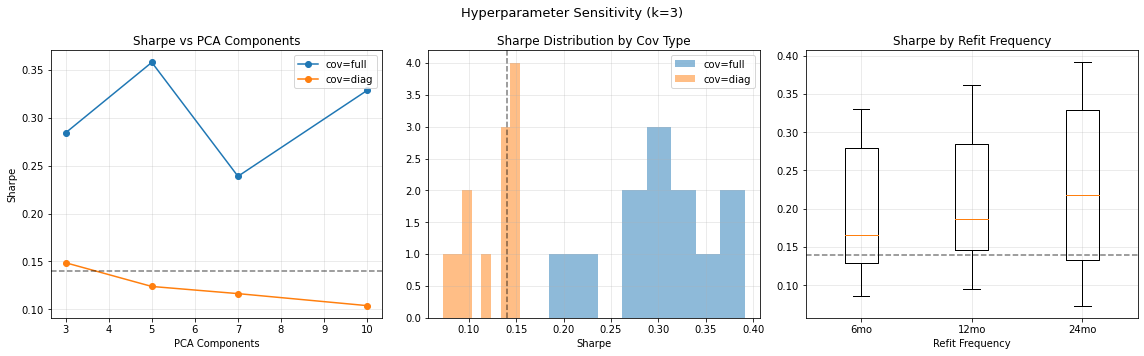

In [8]:
# Visualize: Sharpe by PCA components and covariance type
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# By PCA components
for cov in cov_vals:
    sub = grid_df[grid_df['Cov']==cov].groupby('PCA')['Sharpe'].mean()
    axes[0].plot(sub.index.to_numpy(), sub.values, 'o-', label=f'cov={cov}')
axes[0].axhline(eq_sharpe, color='k', ls='--', alpha=0.5)
axes[0].set_xlabel('PCA Components'); axes[0].set_ylabel('Sharpe')
axes[0].set_title('Sharpe vs PCA Components'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

# By covariance type
for cov in cov_vals:
    sub = grid_df[grid_df['Cov']==cov]['Sharpe']
    axes[1].hist(sub, bins=8, alpha=0.5, label=f'cov={cov}')
axes[1].axvline(eq_sharpe, color='k', ls='--', alpha=0.5)
axes[1].set_xlabel('Sharpe'); axes[1].set_title('Sharpe Distribution by Cov Type')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# By refit frequency
for refit in refit_vals:
    sub = grid_df[grid_df['Refit']==refit]['Sharpe']
    axes[2].boxplot([grid_df[grid_df['Refit']==r]['Sharpe'].values for r in refit_vals],
                     labels=[f'{r}mo' for r in refit_vals])
    break  # only need to call boxplot once
axes[2].axhline(eq_sharpe, color='k', ls='--', alpha=0.5)
axes[2].set_xlabel('Refit Frequency'); axes[2].set_title('Sharpe by Refit Frequency')
axes[2].grid(True, alpha=0.3)

plt.suptitle(f'Hyperparameter Sensitivity (k={best_k})', fontsize=13)
plt.tight_layout(); plt.savefig(f'{RESULTS_DIR}/hyperparam_sensitivity.png', dpi=150); plt.show()

## 5. Transaction cost analysis
Does the strategy survive realistic costs? Test 0, 5, 10, 20, 50 bps per rebalance.

In [9]:
# Use the best config from grid search
best_config = grid_df.iloc[0]
best_pca = int(best_config['PCA'])
best_cov = best_config['Cov']
best_refit = int(best_config['Refit'])
print(f'Best config: PCA={best_pca}, Cov={best_cov}, Refit={best_refit}mo\n')

tc_vals = [0, 5, 10, 20, 50]
tc_results = []

for tc in tc_vals:
    r = run_regime_strategy(macro_aligned, factors_aligned, factor_names,
                            n_regimes=best_k, n_pca=best_pca, refit_every=best_refit,
                            cov_type=best_cov, tc_bps=tc)
    m = compute_metrics(r['strat_rets'], f'{tc}bps')
    m['TC (bps)'] = tc
    tc_results.append(m)

tc_df = pd.DataFrame(tc_results).set_index('model')
print('=== Transaction Cost Impact ===')
print(tc_df[['TC (bps)', 'Ann. Return', 'Sharpe', 'Max DD']].round(4).to_string())
print(f'\nEqual-weight Sharpe (no costs): {eq_sharpe:.3f}')

# At what cost level does the strategy stop beating EW?
for tc_row in tc_results:
    if tc_row['Sharpe'] < eq_sharpe:
        print(f'\nStrategy underperforms EW at {tc_row["TC (bps)"]}bps')
        break
else:
    print(f'\nStrategy beats EW at all tested cost levels')

Best config: PCA=10, Cov=full, Refit=24mo

=== Transaction Cost Impact ===
       TC (bps)  Ann. Return  Sharpe  Max DD
model                                       
0bps          0       0.0174  0.3913 -0.1844
5bps          5       0.0166  0.3724 -0.1883
10bps        10       0.0158  0.3535 -0.1921
20bps        20       0.0141  0.3157 -0.1996
50bps        50       0.0091  0.2026 -0.2218

Equal-weight Sharpe (no costs): 0.140

Strategy beats EW at all tested cost levels


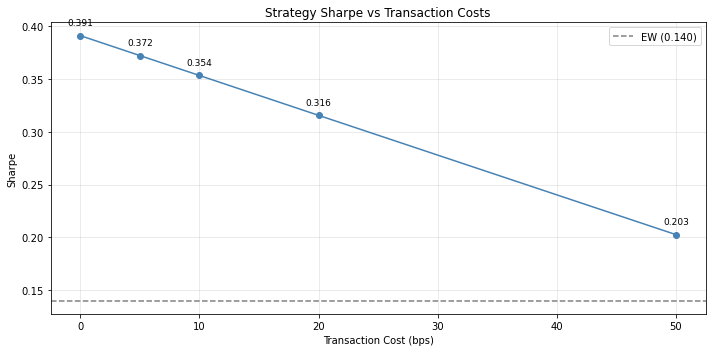

In [10]:
# Plot TC impact
fig, ax = plt.subplots(figsize=(10, 5))
sharpes_tc = [r['Sharpe'] for r in tc_results]
ax.plot(tc_vals, sharpes_tc, 'steelblue', marker='o', lw=1.5)
ax.axhline(eq_sharpe, color='k', ls='--', alpha=0.5, label=f'EW ({eq_sharpe:.3f})')
ax.set_xlabel('Transaction Cost (bps)'); ax.set_ylabel('Sharpe')
ax.set_title('Strategy Sharpe vs Transaction Costs')
ax.legend(); ax.grid(True, alpha=0.3)
for tc, s in zip(tc_vals, sharpes_tc):
    ax.annotate(f'{s:.3f}', (tc, s), textcoords='offset points', xytext=(0,10), ha='center', fontsize=9)
plt.tight_layout(); plt.savefig(f'{RESULTS_DIR}/transaction_costs.png', dpi=150); plt.show()

## 6. Training window robustness
Shift the initial training window (40%, 50%, 60%, 70%) to test sensitivity.

In [11]:
window_results = []

for pct in [0.40, 0.50, 0.60, 0.70]:
    r = run_regime_strategy(macro_aligned, factors_aligned, factor_names,
                            n_regimes=best_k, n_pca=best_pca, refit_every=best_refit,
                            cov_type=best_cov, init_train_pct=pct)
    m = compute_metrics(r['strat_rets'], f'Train={pct:.0%}')
    m_eq = compute_metrics(r['eq_rets'])
    m['Train %'] = pct
    m['OOS months'] = len(r['strat_rets'])
    m['EW Sharpe'] = m_eq['Sharpe']
    m['Excess Sharpe'] = m['Sharpe'] - m_eq['Sharpe']
    window_results.append(m)

window_df = pd.DataFrame(window_results).set_index('model')
print('=== Training Window Sensitivity ===')
print(window_df[['Train %', 'OOS months', 'Sharpe', 'EW Sharpe', 'Excess Sharpe', 'Max DD']].round(4).to_string())

all_positive = all(r['Excess Sharpe'] > 0 for r in window_results)
print(f'\nStrategy beats EW in all windows: {"YES" if all_positive else "NO"}')

=== Training Window Sensitivity ===
           Train %  OOS months  Sharpe  EW Sharpe  Excess Sharpe  Max DD
model                                                                   
Train=40%      0.4         302  0.2810     0.3599        -0.0789 -0.2129
Train=50%      0.5         251  0.3913     0.1400         0.2513 -0.1844
Train=60%      0.6         201  0.2292     0.1228         0.1065 -0.1914
Train=70%      0.7         151  0.2205     0.0243         0.1961 -0.1591

Strategy beats EW in all windows: NO


## 7. Best configuration: deep-dive analysis
Statistical tests, per-regime breakdown, and regime interpretation.

In [12]:
# Run best config
print(f'Best config: k={best_k}, PCA={best_pca}, Cov={best_cov}, Refit={best_refit}mo')
result = run_regime_strategy(macro_aligned, factors_aligned, factor_names,
                              n_regimes=best_k, n_pca=best_pca, refit_every=best_refit,
                              cov_type=best_cov)

m_strat = compute_metrics(result['strat_rets'], 'Regime-Conditioned')
m_eq = compute_metrics(result['eq_rets'], 'Equal-Weight')
m_static = compute_metrics(result['static_rets'], 'Static Best Mix')

print(f'\n=== Results ===')
for m in [m_strat, m_eq, m_static]:
    print(f'  {m["model"]:25s}: Sharpe={m["Sharpe"]:.3f}, Return={m["Ann. Return"]:.2%}, MaxDD={m["Max DD"]:.1%}')

Best config: k=3, PCA=10, Cov=full, Refit=24mo

=== Results ===
  Regime-Conditioned       : Sharpe=0.391, Return=1.74%, MaxDD=-18.4%
  Equal-Weight             : Sharpe=0.140, Return=0.61%, MaxDD=-15.5%
  Static Best Mix          : Sharpe=0.179, Return=0.97%, MaxDD=-23.1%


In [13]:
# Statistical tests
excess = result['strat_rets'] - result['eq_rets']
t_stat, p_val = stats.ttest_1samp(excess, 0)
ir = np.mean(excess) / np.std(excess) * np.sqrt(12) if np.std(excess) > 0 else 0
hit_rate = np.mean(excess > 0)

print('=== Statistical Significance ===')
print(f'  Annualized excess return: {np.mean(excess)*12:.2%}')
print(f'  Information ratio:        {ir:.3f}')
print(f'  Hit rate:                 {hit_rate:.1%}')
print(f'  t-statistic:              {t_stat:.3f}')
print(f'  p-value:                  {p_val:.4f} {"***" if p_val<0.01 else "**" if p_val<0.05 else "*" if p_val<0.10 else ""}')

# Bootstrap confidence interval for Sharpe
np.random.seed(42)
n_boot = 5000
boot_sharpes = []
for _ in range(n_boot):
    idx = np.random.choice(len(result['strat_rets']), size=len(result['strat_rets']), replace=True)
    boot_rets = result['strat_rets'][idx]
    boot_s = np.mean(boot_rets) / np.std(boot_rets) * np.sqrt(12) if np.std(boot_rets)>0 else 0
    boot_sharpes.append(boot_s)
ci_lo, ci_hi = np.percentile(boot_sharpes, [2.5, 97.5])
print(f'  Sharpe 95% CI:            [{ci_lo:.3f}, {ci_hi:.3f}]')

=== Statistical Significance ===
  Annualized excess return: 1.13%
  Information ratio:        0.459
  Hit rate:                 59.4%
  t-statistic:              2.095
  p-value:                  0.0372 **
  Sharpe 95% CI:            [-0.018, 0.847]


In [14]:
# Per-regime breakdown
print(f'\n=== Per-Regime Performance ===')
factors_oos = factors_aligned.loc[pd.DatetimeIndex(result['dates'])]
for r in range(best_k):
    mask = result['regimes'] == r
    if mask.sum() < 3: continue
    r_rets = result['strat_rets'][mask]
    eq_r = result['eq_rets'][mask]
    s_s = r_rets.mean()/r_rets.std()*np.sqrt(12) if r_rets.std()>0 else 0
    s_e = eq_r.mean()/eq_r.std()*np.sqrt(12) if eq_r.std()>0 else 0
    va = (r_rets.mean()-eq_r.mean())*100
    avg_w = result['weights'][mask].mean(axis=0)
    w_str = ' '.join([f'{f}={w:.2f}' for f,w in zip(factor_names, avg_w)])
    
    # Factor performance in this regime
    regime_f = factors_oos[mask]
    best_f = (regime_f.mean()*100).idxmax()
    worst_f = (regime_f.mean()*100).idxmin()
    
    print(f'\nRegime {r} ({mask.sum()} months):')
    print(f'  Sharpe: {s_s:+.2f} (EW: {s_e:+.2f}), value-add: {va:+.3f}%/mo')
    print(f'  Weights: {w_str}')
    print(f'  Best factor: {best_f} ({regime_f[best_f].mean()*100:+.3f}%/mo), Worst: {worst_f} ({regime_f[worst_f].mean()*100:+.3f}%/mo)')


=== Per-Regime Performance ===

Regime 0 (78 months):
  Sharpe: +0.90 (EW: +0.29), value-add: +0.255%/mo
  Weights: SMB=0.09 HML=0.19 RMW=0.26 CMA=0.14 Mom=0.31
  Best factor: HML (+0.617%/mo), Worst: SMB (-0.454%/mo)

Regime 1 (59 months):
  Sharpe: +0.18 (EW: -0.11), value-add: +0.103%/mo
  Weights: SMB=0.13 HML=0.20 RMW=0.24 CMA=0.16 Mom=0.27
  Best factor: Mom (+0.866%/mo), Worst: HML (-0.657%/mo)

Regime 2 (114 months):
  Sharpe: +0.13 (EW: +0.19), value-add: -0.021%/mo
  Weights: SMB=0.09 HML=0.17 RMW=0.26 CMA=0.21 Mom=0.27
  Best factor: RMW (+0.367%/mo), Worst: HML (-0.221%/mo)


In [15]:
# Regime macro characteristics
macro_oos = macro_aligned.loc[pd.DatetimeIndex(result['dates'])]
regime_series = pd.Series(result['regimes'], index=result['dates'])

print(f'\n=== Regime Characteristics ===')
for r in range(best_k):
    mask = regime_series == r
    if mask.sum() < 3: continue
    z = (macro_oos[mask].mean() - macro_oos.mean()) / macro_oos.std().replace(0,1)
    print(f'\nRegime {r} ({mask.sum()} months):')
    print(f'  Elevated: ', end='')
    for v, zs in z.nlargest(5).items(): print(f'{v}({zs:+.2f}) ', end='')
    print(f'\n  Depressed: ', end='')
    for v, zs in z.nsmallest(5).items(): print(f'{v}({zs:+.2f}) ', end='')
    print()


=== Regime Characteristics ===

Regime 0 (78 months):
  Elevated: GS1(+0.29) TB6MS(+0.28) GS10(+0.26) TB3MS(+0.25) FEDFUNDS(+0.24) 
  Depressed: M2REAL(-0.36) DPIC96(-0.09) UNRATE(-0.07) CES0600000007(-0.07) UEMPMEAN(-0.07) 

Regime 1 (59 months):
  Elevated: M2REAL(+0.39) DPIC96(+0.29) HOUST(+0.22) UNRATE(+0.20) CES0600000007(+0.16) 
  Depressed: FEDFUNDS(-0.26) TB6MS(-0.19) TB3MS(-0.16) GS1(-0.15) INDPRO(-0.12) 

Regime 2 (114 months):
  Elevated: M2REAL(+0.04) UEMPMEAN(+0.04) CES3000000008(+0.04) OILPRICEx(+0.02) INDPRO(+0.02) 
  Depressed: GS10(-0.19) HOUST(-0.19) GS1(-0.12) TB6MS(-0.10) DPIC96(-0.09) 


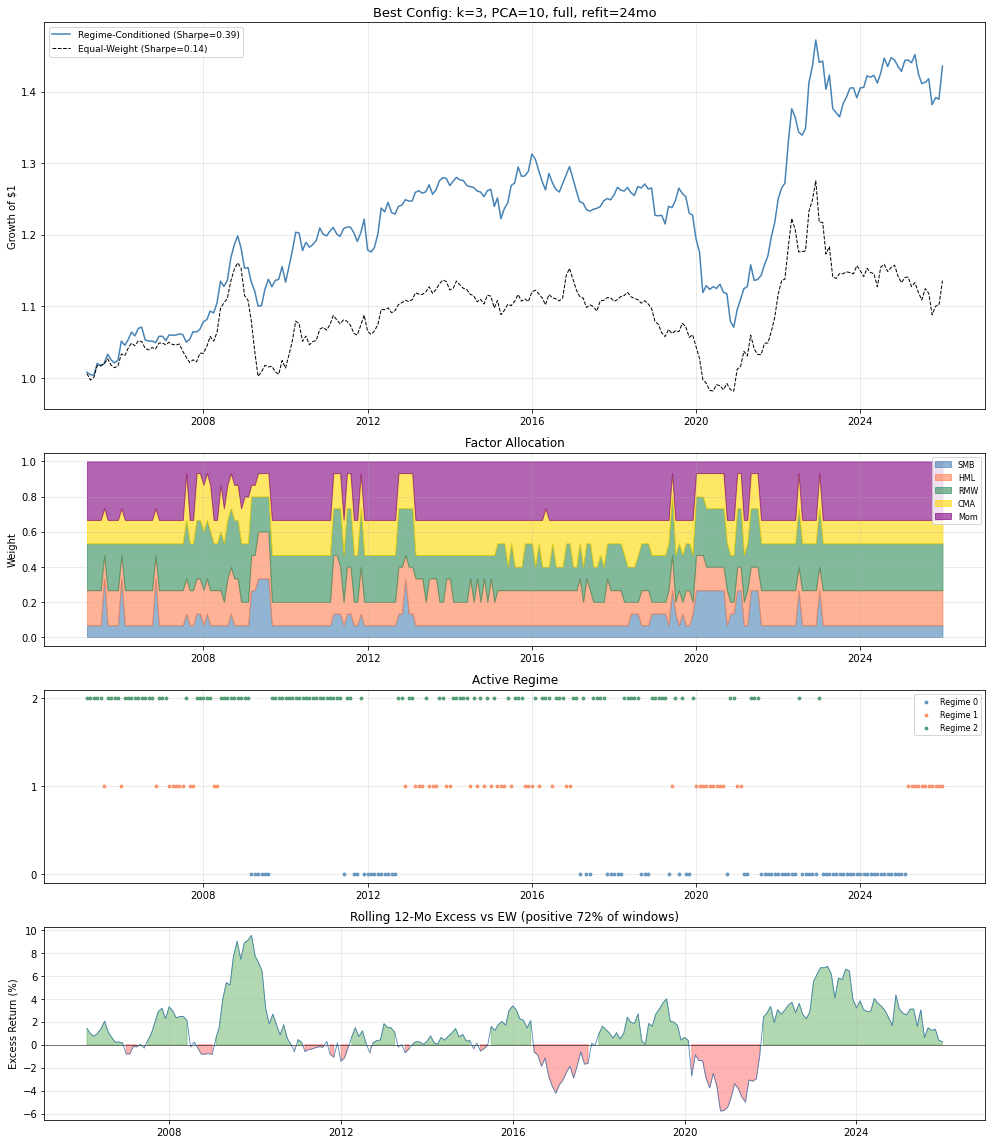

In [16]:
# Main plots
fig, axes = plt.subplots(4, 1, figsize=(14, 16), gridspec_kw={'height_ratios': [2, 1, 1, 1]})

# 1. Cumulative returns
strat_cum = np.cumprod(1 + result['strat_rets'])
eq_cum = np.cumprod(1 + result['eq_rets'])
axes[0].plot(result['dates'], strat_cum, 'steelblue', lw=1.5,
             label=f'Regime-Conditioned (Sharpe={m_strat["Sharpe"]:.2f})')
axes[0].plot(result['dates'], eq_cum, 'k--', lw=1,
             label=f'Equal-Weight (Sharpe={m_eq["Sharpe"]:.2f})')
axes[0].set_title(f'Best Config: k={best_k}, PCA={best_pca}, {best_cov}, refit={best_refit}mo', fontsize=13)
axes[0].set_ylabel('Growth of $1'); axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

# 2. Factor weights
colors = ['steelblue','coral','seagreen','gold','purple']
bottom = np.zeros(len(result['dates']))
for a in range(len(factor_names)):
    axes[1].fill_between(result['dates'], bottom, bottom+result['weights'][:,a],
                         alpha=0.6, color=colors[a], label=factor_names[a])
    bottom += result['weights'][:,a]
axes[1].set_ylabel('Weight'); axes[1].set_title('Factor Allocation')
axes[1].legend(fontsize=8, loc='upper right'); axes[1].grid(True, alpha=0.3)

# 3. Regimes
colors_map = {0:'steelblue',1:'coral',2:'seagreen',3:'gold',4:'purple'}
for r in range(best_k):
    mask = result['regimes']==r
    axes[2].scatter(result['dates'][mask], result['regimes'][mask],
                    c=colors_map[r], s=8, alpha=0.8, label=f'Regime {r}')
axes[2].set_yticks(range(best_k)); axes[2].set_title('Active Regime')
axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.3)

# 4. Rolling excess return
excess_s = pd.Series(result['strat_rets']-result['eq_rets'], index=result['dates'])
roll_ex = excess_s.rolling(12).sum()*100
axes[3].plot(roll_ex.index.to_numpy(), roll_ex.values, 'steelblue', lw=0.8)
axes[3].fill_between(roll_ex.index.to_numpy(), 0, roll_ex.values,
                      where=roll_ex.values>0, alpha=0.3, color='green')
axes[3].fill_between(roll_ex.index.to_numpy(), 0, roll_ex.values,
                      where=roll_ex.values<=0, alpha=0.3, color='red')
axes[3].axhline(0, color='k', lw=0.5)
pct_out = (roll_ex.dropna()>0).mean()
axes[3].set_title(f'Rolling 12-Mo Excess vs EW (positive {pct_out:.0%} of windows)')
axes[3].set_ylabel('Excess Return (%)'); axes[3].grid(True, alpha=0.3)

plt.tight_layout(); plt.savefig(f'{RESULTS_DIR}/best_config_detail.png', dpi=150); plt.show()

## 8. Save results

In [ ]:
sweep_df.to_csv(f'{RESULTS_DIR}/regime_sweep.csv')
grid_df.to_csv(f'{RESULTS_DIR}/regime_grid_search.csv')
tc_df.to_csv(f'{RESULTS_DIR}/regime_transaction_costs.csv')
window_df.to_csv(f'{RESULTS_DIR}/regime_window_robustness.csv')

# Save best config weights and regimes
pd.DataFrame(result['weights'], columns=factor_names, index=result['dates']).to_csv(
    f'{RESULTS_DIR}/best_regime_weights.csv')
pd.DataFrame({'regime': result['regimes']}, index=result['dates']).to_csv(
    f'{RESULTS_DIR}/best_regime_assignments.csv')

print('All results saved.')
print(f'\nBest config: k={best_k}, PCA={best_pca}, Cov={best_cov}, Refit={best_refit}mo')
print(f'Sharpe: {m_strat["Sharpe"]:.3f} (EW: {m_eq["Sharpe"]:.3f})')
print(f'p-value: {p_val:.4f}')

## Summary

### What we tested
- **Regime count**: k=2,3,4,5 — is the result robust across regime counts?
- **Hyperparameters**: PCA components (3,5,7,10) × GMM covariance (full, diag) × refit frequency (6,12,24mo)
- **Transaction costs**: 0-50 bps — does the strategy survive realistic costs?
- **Training window**: 40-70% initial training — sensitive to how much history we use?
- **Statistical significance**: t-test, information ratio, bootstrap CI for Sharpe

### Implementation
Monthly process:
1. Pull FRED data via API
2. Standardize, PCA, classify with GMM
3. Look up factor tilt for current regime
4. Rebalance if regime changed
No neural networks, no complex infrastructure.